<a href="https://colab.research.google.com/github/daveveed/Geo-Data-Science/blob/main/Representation_of_vector_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## creating Point geometries

In [ ]:
from shapely.geometry import Point, LineString, Polygon

In [ ]:
point = Point(2.2, 4.2)

In [ ]:
point3D = Point(2.2, 4.2, 5.3)

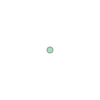

In [ ]:
point

to get the WKT format use print

In [ ]:
print(point)

POINT (2.2 4.2)


In [ ]:
print(point3D)

POINT Z (2.2 4.2 5.3)


In [ ]:
#wkt string representation
point.wkt

'POINT (2.2 4.2)'

Points and other shapely objects have many useful built-in attributes and methods for extracting information from the geometric objects, such as the coordinates of a point. There are different approaches for extracting coordinates as numerical values from the shapely objects. One of them is a property called .coords. It returns the coordinates of the point geometry as a CoordinateSequence which is a dedicated data structure for storing a list of coordinates. For our purposes, we can convert the coordinates into a list that makes the values visible and make it easy to access the contents:

In [ ]:
point.coords

In [ ]:
list(point.coords)

[(2.2, 4.2)]

In [ ]:
point.x

2.2

In [ ]:
point.y

4.2

## Line

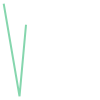

In [ ]:
point1 = Point(2.2, 4.2)
point2 = Point(7.2, -25.1)
point3 = Point(9.26, -2.456)

line = LineString([point1, point2, point3])
line_from_tuples = LineString([(2.2, 4.2), (7.2, -25.1), (9.26, -2.456)])
line

In [ ]:
line.wkt

'LINESTRING (2.2 4.2, 7.2 -25.1, 9.26 -2.456)'

In [ ]:
line.coords

In [ ]:
list(line.coords)

[(2.2, 4.2), (7.2, -25.1), (9.26, -2.456)]

In [ ]:
xcoords = list(line.coords.xy[0])
ycoords = list(line.coords.xy[1])

In [ ]:
print(xcoords)
print(ycoords)

[2.2, 7.2, 9.26]
[4.2, -25.1, -2.456]


In [ ]:
length = line.length

In [ ]:
print (length)

52.46106912939557


In [ ]:
centriod = line.centroid
print(centriod)

POINT (6.229961354035622 -11.892411157572392)


## Polygon

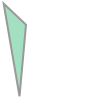

In [ ]:
poly = Polygon([point1, point2, point3])
poly

In [ ]:
poly.wkt

'POLYGON ((2.2 4.2, 7.2 -25.1, 9.26 -2.456, 2.2 4.2))'

Notice that the Polygon WKT representation has double parentheses around the coordinates (i.e. POLYGON ((<values in here>)) ). The current set of coordinates represents the outlines of the shape, i.e. the exterior of the polygon. However, a Polygon can also contain an optional interior rings, that can be used to represent holes in the polygon.

If we want to create a polygon with a hole, we can do this by using parameters shell for the exterior and holes for the interiors as follows. Notice that because a Polygon can have multiple holes, the holes_coordinates variable below contains nested square brackets ([[ ]]), which is due to the possibility of having multiple holes in a single Polygon. First, let’s define the coordinates for the exterior and interior rings:

In [ ]:
# exterior coords
exterior = [(-180, 90), (-180, -90), (180, -90), (180, 90)]

# interior coords / hole
interior = [[(-170, 80), (-170, -80), (170, -80), (170, 80)]]

poly_without_hole = Polygon(shell=exterior)
poly_with_hole = Polygon(shell=exterior, holes=interior)

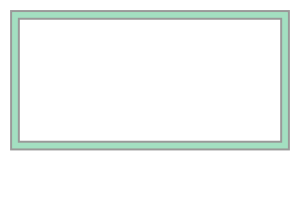

In [ ]:
poly_with_hole

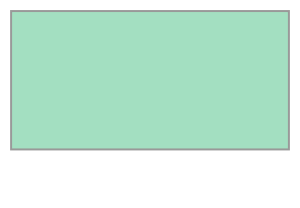

In [ ]:
poly_without_hole

In [ ]:
poly_with_hole.wkt

'POLYGON ((-180 90, -180 -90, 180 -90, 180 90, -180 90), (-170 80, -170 -80, 170 -80, 170 80, -170 80))'

In [ ]:
list(poly_with_hole.exterior.coords)

[(-180.0, 90.0),
 (-180.0, -90.0),
 (180.0, -90.0),
 (180.0, 90.0),
 (-180.0, 90.0)]

In [ ]:
x = list(poly_with_hole.exterior.coords.xy[0])
y = list(poly_with_hole.exterior.coords.xy[1])

In [ ]:
x

[-180.0, -180.0, 180.0, 180.0, -180.0]

In [ ]:
y

[90.0, -90.0, -90.0, 90.0, 90.0]

In [ ]:
print("Polygon centroid: ", poly.centroid)
print("Polygon Area: ", poly.area)
print("Polygon Bounding Box: ", poly.bounds)
print("Polygon Exterior: ", poly.exterior)
print("Polygon Exterior Length: ", poly.exterior.length)

Polygon centroid:  POINT (6.22 -7.785333333333334)
Polygon Area:  86.789
Polygon Bounding Box:  (2.2, -25.1, 9.26, 4.2)
Polygon Exterior:  LINEARRING (2.2 4.2, 7.2 -25.1, 9.26 -2.456, 2.2 4.2)
Polygon Exterior Length:  62.16395199996553


Box polygons that represent the minimum bounding box of given coordinates are useful in many applications. shapely.box can be used for creating rectangular box polygons based on on minimum and maximum x and y coordinates that represent the coordinate information of the bottom-left and top-right corners of the rectangle. Here we will use shapely.box to re-create the same polygon exterior.

POLYGON ((180 -90, 180 90, -180 90, -180 -90, 180 -90))
POLYGON ((180 -90, 180 90, -180 90, -180 -90, 180 -90))


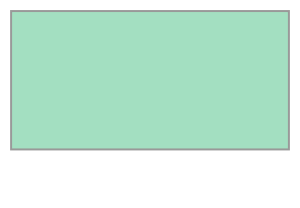

In [ ]:
from shapely.geometry import box

min_x, min_y = -180, -90
max_x, max_y = 180, 90

bbox = box(minx=min_x, miny=min_y, maxx=max_x, maxy=max_y)
print(bbox)
print(bbox.wkt)
bbox

In [ ]:
min_x,min_y, max_x,max_y = 2.2, -25.1, 9.26, 4.2 #testing for the triangle above

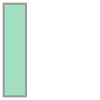

In [ ]:
poly_box = box(minx=min_x, miny=min_y, maxx=max_x, maxy=max_y)
poly_box

## Creating MultiPoint, MultiLineString and MultiPolygon geometries

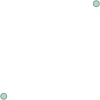

In [ ]:
from shapely import MultiPoint, MultiLineString, MultiPolygon

multipoint = MultiPoint([Point(2, 2), Point(3, 3)])
multipoint

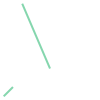

In [ ]:
multiline = MultiLineString([LineString([(0, 0), (1, 1)]), LineString([(2,10), (5, 3)])])
multiline

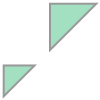

In [ ]:
multipoly = MultiPolygon(
    [Polygon([(0, 0), (0, 4), (4, 4)]), Polygon([(6, 6), (6, 12), (12, 12)])]
)
multipoly

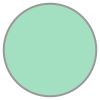

In [ ]:
# Circle (using a buffer around a point)
point = Point((0, 0))
point.buffer(1)

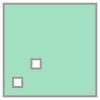

In [ ]:
exterior_coords = [(0, 0), (0, 10), (10, 10), (10, 0), (0, 0)]
hole1_coords = [(1, 1), (1, 2), (2, 2), (2, 1), (1, 1)]
hole2_coords = [(3, 3), (3, 4), (4, 4), (4, 3), (3, 3)]

polygon_with_two_holes = Polygon(shell=exterior_coords, holes=[hole1_coords, hole2_coords])
polygon_with_two_holes